# Perceptrón de Rosenblatt desde cero

## Propósito

En clase diseñamos conjuntamente la arquitectura funcional de un perceptrón de Rosenblatt.  
Este cuaderno parte de esa arquitectura y tiene un objetivo concreto:

> **completar la implementación de las funciones sin modificar la arquitectura acordada.**

El cuaderno contiene el enunciado, los datos, el EDA, las pruebas, los experimentos y las visualizaciones.  
Usted debe programar únicamente el cuerpo de las funciones marcadas con:

**`CELDA A COMPLETAR`**

Si las funciones cumplen sus contratos, al finalizar podrá ejecutar:

**Restart Kernel → Run All**

y el cuaderno deberá correr de principio a fin sin errores.

---

### Reglas de trabajo

1. **No cambie** el nombre de las funciones.
2. **No cambie** los argumentos ni los `type hints`.
3. **No cambie** el nombre de las variables indicadas en los `return`.
4. No modifique las celdas marcadas como **PRUEBA — NO MODIFICAR**.
5. Puede crear variables auxiliares dentro de una función.
6. El núcleo del perceptrón debe implementarse con **NumPy**. No utilice una implementación de perceptrón de `scikit-learn`, TensorFlow, PyTorch u otra biblioteca.
7. Las validaciones deben detener la ejecución mediante `raise ValueError(...)` cuando se incumpla el contrato especificado.
8. Cuando termine, ejecute todo el cuaderno desde un kernel limpio antes de hacer `commit` y `push`.

---

### Dependencias

En el ambiente del curso deben estar disponibles, como mínimo:

```bash
uv add numpy pandas matplotlib
```

El ambiente virtual **no se sube a GitHub**. Se versionan el código, el notebook, `pyproject.toml` y `uv.lock`.

## 1. La arquitectura que vamos a implementar

Ya discutimos que no queremos una única función enorme. El algoritmo se descompone en operaciones pequeñas que luego son coordinadas por funciones de mayor nivel.

| Tipo | Función | Responsabilidad |
|---|---|---|
| Elemental | `validar_datos` | Verificar que \(X\) e \(y\) cumplen el contrato del algoritmo. |
| Elemental | `agregar_sesgo` | Construir \(\tilde X=[\mathbf 1\mid X]\). |
| Elemental | `inicializar_pesos` | Crear \(\mathbf w\in\mathbb{R}^{d+1}\). |
| Elemental | `entrada_neta` | Calcular \(z=\mathbf w^\top\tilde{\mathbf x}\). |
| Elemental | `signo` | Convertir \(z\) en una etiqueta \(-1\) o \(+1\). |
| Elemental | `esta_mal_clasificado` | Evaluar si \(y_i(\mathbf w^\top\tilde{\mathbf x}_i)\le 0\). |
| Elemental | `actualizar_pesos` | Aplicar la regla de Rosenblatt. |
| Coordinación | `entrenar_una_epoca` | Recorrer una vez el conjunto de entrenamiento. |
| Coordinación | `entrenar_perceptron` | Coordinar múltiples épocas y almacenar el historial. |
| Coordinación | `predecir` | Obtener predicciones para un conjunto de observaciones. |

La conexión principal es:

\[
X,y
\longrightarrow
\texttt{validar\_datos}
\longrightarrow
\texttt{agregar\_sesgo}
\longrightarrow
\texttt{entrenar\_perceptron}.
\]

Durante cada época:

\[
\tilde{\mathbf x}_i
\rightarrow
\texttt{entrada\_neta}
\rightarrow
\texttt{esta\_mal\_clasificado}
\rightarrow
\texttt{actualizar\_pesos}.
\]

Para inferencia:

\[
X
\rightarrow
\texttt{agregar\_sesgo}
\rightarrow
\texttt{entrada\_neta}
\rightarrow
\texttt{signo}
\rightarrow
\hat y.
\]

## 2. Convención matemática

Trabajaremos con clasificación binaria:

\[
y_i\in\{-1,+1\}.
\]

No utilizaremos un sesgo \(b\) separado. Añadimos una característica constante:

\[
x_0=1,
\]

de manera que

\[
\tilde{\mathbf x}_i=
\begin{bmatrix}
1 & x_{i1} & \cdots & x_{id}
\end{bmatrix}^{\top},
\qquad
\mathbf w=
\begin{bmatrix}
w_0 & w_1 & \cdots & w_d
\end{bmatrix}^{\top}.
\]

Así,

\[
z_i=\mathbf w^\top\tilde{\mathbf x}_i.
\]

La decisión será

\[
\hat y_i=
\begin{cases}
+1,& z_i>0,\\
-1,& z_i\le 0.
\end{cases}
\]

Consideramos que una observación requiere actualización cuando

\[
y_i\,(\mathbf w^\top\tilde{\mathbf x}_i)\le 0.
\]

En ese caso aplicamos la regla de Rosenblatt:

\[
\boxed{
\mathbf w\leftarrow
\mathbf w+\eta y_i\tilde{\mathbf x}_i
}
\]

con \(\eta>0\).

**Importante:** en esta implementación la actualización se realiza únicamente cuando se incumple el criterio anterior.

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 3. Datos del laboratorio

El notebook es autocontenido: los conjuntos utilizados se generan dentro del propio cuaderno.

Trabajaremos con tres problemas:

- **AND**, para verificar el comportamiento en un problema pequeño y linealmente separable;
- **XOR**, para distinguir un error de software de una limitación de representación;
- un **conjunto sintético bidimensional** con suficientes observaciones para separar entrenamiento, validación y prueba.

Las funciones de esta sección ya están implementadas. **No las modifique.**

In [ ]:
def crear_and() -> tuple[np.ndarray, np.ndarray]:
    X = np.array(       # combinaciones posibles de entradas binarias
        [
            [0.0, 0.0],
            [0.0, 1.0],
            [1.0, 0.0],
            [1.0, 1.0],
        ]
    )
    y = np.array([-1, -1, -1, 1], dtype=int)    #tiene que ver con los "verdadeeros" del operador AND
    return X, y


def crear_xor() -> tuple[np.ndarray, np.ndarray]:
    X = np.array(   #otra vez las posibles combinaciones
        [
            [0.0, 0.0],
            [0.0, 1.0],
            [1.0, 0.0],
            [1.0, 1.0],
        ]
    )
    y = np.array([-1, 1, 1, -1], dtype=int)     # etiquetas de verdad para XOR
    return X, y


def crear_datos_sinteticos(
    n: int = 600,
    semilla: int = 2026,
) -> tuple[np.ndarray, np.ndarray]:
    if n < 20:     # n debe ser grande para que tenga sentido el experimento
        raise ValueError("n debe ser al menos 20.")
    
    if n % 2 != 0:     #n debe ser par para partir las mitades
        raise ValueError("n debe ser par para mantener balance de clases.")

    rng = np.random.default_rng(semilla)    # numeros aleatorios reproducibles(seed)
    mitad = n // 2    #observaciones por clase

    clase_negativa = rng.normal(     #esto es una nube gaussiana
        loc=(-2.0, -1.5),             #centro de la nube
        scale=(0.5, 0.5),             #desviacion de cada eje
        size=(mitad, 2),              #cuantos puntos y cuantas dimensiones
    )
    clase_positiva = rng.normal(     #nube gaussiana tambien
        loc=(2.0, 1.5),               #mismos parametros que el anterior
        scale=(0.5, 0.5),
        size=(mitad, 2),
    )

    X = np.vstack((clase_negativa, clase_positiva))   #se apilan las caracteristicas en una misma matriz
    y = np.concatenate(           #estas son las etiquetas
        (
            -np.ones(mitad, dtype=int),
            np.ones(mitad, dtype=int),
        )
    )

    indices = rng.permutation(n)   #es una mezcla para que las clases no queden juntas
    return X[indices], y[indices]


def particion_estratificada(
    X: np.ndarray,
    y: np.ndarray,
    proporcion_train: float = 0.70,
    proporcion_val: float = 0.15,
    semilla: int = 2026,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if not 0 < proporcion_train < 1:    #intervalo necesario en estos casos
        raise ValueError("proporcion_train debe pertenecer a (0, 1).")
    if not 0 < proporcion_val < 1:
        raise ValueError("proporcion_val debe pertenecer a (0, 1).")
    if proporcion_train + proporcion_val >= 1:    #por esos intervalos, si la suma entre train y val  ya cubre todo o mas, pues no queda nada para test
        raise ValueError("Debe quedar una proporción positiva para test.")

    rng = np.random.default_rng(semilla)   #semilla reproducible

    grupos = {}  #vamos a ir guardando los indices ya mezclados para separar proporcionalmente
    for etiqueta in np.unique(y):
        idx = np.flatnonzero(y == etiqueta)    #indices en una clase
        grupos[etiqueta] = rng.permutation(idx)    #mezclar

    train_idx, val_idx, test_idx = [], [], []    #la particion 

    for idx in grupos.values():
        n_clase = len(idx)
        n_train = int(round(proporcion_train * n_clase))    #cuantos a train
        n_val = int(round(proporcion_val * n_clase))       #cuantos a validaiton

        train_idx.extend(idx[:n_train])      #primeros n_train
        val_idx.extend(idx[n_train:n_train + n_val])    #siguientes n_Val
        test_idx.extend(idx[n_train + n_val:])        #los demas

    #como igual estan ordenados dentro de cada clase, mezclamos otra vez cada una
    train_idx = rng.permutation(train_idx)
    val_idx = rng.permutation(val_idx)
    test_idx = rng.permutation(test_idx)

    return (            #X y Y de cada uno de los tres subconjuntos de la partición
        X[train_idx], y[train_idx],
        X[val_idx], y[val_idx],
        X[test_idx], y[test_idx],
    )

## 4. Antes de modelar: una exploración mínima de los datos

Antes de entrenar debemos saber qué recibimos. No se trata de ejecutar una lista mecánica de comandos, sino de responder preguntas concretas:

- ¿cuántas observaciones tenemos?;
- ¿qué variables aparecen?;
- ¿son numéricas?;
- ¿hay valores faltantes?;
- ¿las clases están balanceadas?;
- ¿la geometría de los datos sugiere que una frontera lineal puede ser razonable?

Esta inspección **no demuestra** separabilidad lineal. Es una primera lectura del problema.

In [3]:
X_sint, y_sint = crear_datos_sinteticos()    #generar el conjunto sintético (n=600 por default)

datos = pd.DataFrame(
    {
        "x1": X_sint[:, 0],    # primera columna de X, variable x1
        "x2": X_sint[:, 1],    # segunda columna de X, variable x2
        "y": y_sint,           # etiqueta para cada observación
    }
)

datos.head()    #vistazo del conjunto

,x1,x2,y
0,1.288627,1.814144,1
1,2.654189,0.716286,1
2,-1.583039,-0.931142,-1
3,2.337029,1.732470,1
4,-2.365623,-1.366143,-1


In [4]:
print("Forma:", datos.shape)    #( observaciones,columnas ) : total de datos
print("\nTipos:")
print(datos.dtypes)     #tipo de dato por columna (var. numéricas)

print("\nValores faltantes:")
print(datos.isna().sum())         #rectificamos que no hay faltantes

print("\nDistribución de clases:")
print(datos["y"].value_counts().sort_index())    #conteo de -1 y +1 (debe estar balanceado)

Forma: (600, 3)

Tipos:
x1    float64
x2    float64
y       int64
dtype: object

Valores faltantes:
x1    0
x2    0
y     0
dtype: int64

Distribución de clases:
y
-1    300
 1    300
Name: count, dtype: int64


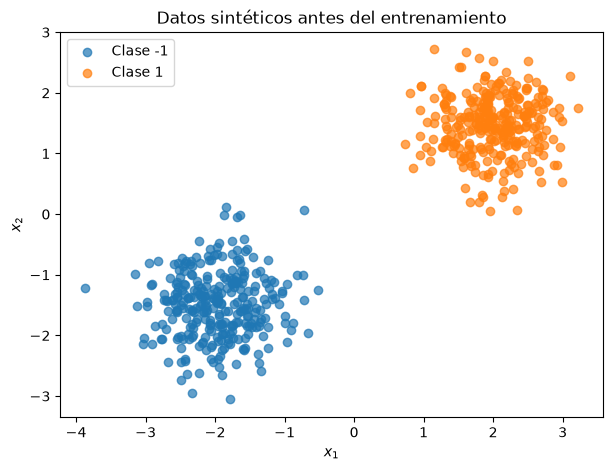

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))    #un grafico de dsipersión

for etiqueta in (-1, 1):
    grupo = datos[datos["y"] == etiqueta]    # filtramos solo las filas de esa clase
    ax.scatter(
        grupo["x1"],
        grupo["x2"],
        alpha=0.7,                       
        label=f"Clase {etiqueta}",
    )

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Datos sintéticos antes del entrenamiento")
ax.legend()
plt.show()    #vemos la figura ya renderizada

### Pregunta antes de continuar

A partir de la gráfica:

1. ¿parece plausible separar las clases mediante una recta?; 
Si, el grafico de dispersión muestra dos nubes claramente separadas

2. ¿qué parte de esa afirmación es observación visual y qué parte requeriría una demostración?;
Las vemos separadas de forma visual, pero demostrar la separabilidad lineal requiere de encontrar un hiperplano que las separe

3. ¿por qué una buena visualización no sustituye la evaluación sobre datos no utilizados para entrenar?
Porque el gráfico solo muestra cómo se ven los datos, no cómo se comporta el modelo entrenado sobre ellos. El perceptrón podría fallar en datos nuevos.

No necesita escribir aquí una respuesta extensa, pero tenga estas preguntas presentes durante el experimento.

# 5. Implementación funcional del perceptrón

A partir de aquí comienzan las celdas que debe completar.

Cada función tiene:

- firma;
- `type hints`;
- docstring;
- variable de salida;
- `return`.

Su tarea es implementar **solo la lógica interna**.

Después de cada función encontrará una celda de prueba.  
No continúe si la prueba anterior falla.

## 5.1 `validar_datos`

El algoritmo espera

\[
X\in\mathbb{R}^{n\times d},
\qquad
y\in\{-1,+1\}^{n}.
\]

La función debe verificar, como mínimo:

- `X` es bidimensional;
- `y` es unidimensional;
- ambos contienen el mismo número de observaciones;
- `X` contiene únicamente valores finitos;
- `y` contiene únicamente \(-1\) y \(+1\).

Si alguna condición no se cumple, utilice:

```python
raise ValueError("mensaje que explique el problema")
```

Validar no significa corregir silenciosamente los datos.

In [6]:
def validar_datos(     #primera funcion elemental que aplico
    X: np.ndarray,
    y: np.ndarray,
) -> bool:
    """Valida el contrato de entrada del perceptrón.

    Args:
        X: Matriz de características de forma (n_observaciones, n_caracteristicas).
        y: Vector de etiquetas binarias en {-1, +1}.

    Returns:
        True si los datos cumplen todas las condiciones requeridas.

    Raises:
        ValueError: Si las dimensiones, valores o etiquetas no son válidos.
    """

    # no deberian existir valores raros o no definidos, como nan o infinitos
    if not np.isfinite(X).all():
        raise ValueError("X contiene valores no finitos (NaN o infinitos).")

    # y debe ser unidimensional (observaciones)
    if y.ndim != 1:
        raise ValueError(f"y debe ser unidimensional, pero tiene ndim={y.ndim}.")

    # queremos que X sea matriz bidmensional
    if X.ndim != 2:
        raise ValueError(f"X debe ser bidimensional, pero tiene ndim={X.ndim}.")

    # X y Y representan las mismas observaciones, entonces verificamos que
    if X.shape[0] != y.shape[0]:
        raise ValueError(
            f"X tiene {X.shape[0]} observaciones pero y tiene {y.shape[0]}."
        )

    # y puede ser solo -1 0 +1 (enteros)
    etiquetas_presentes = set(np.unique(y))
    if not etiquetas_presentes.issubset({-1, 1}):
        raise ValueError(
            f"y solo puede contener -1 y +1, se encontraron: {etiquetas_presentes}."
        )

    
    return True   # Si todo cumple las condiciones    

In [7]:
# PRUEBA — NO MODIFICAR

# para devolver True: X debe ser bidimensional, y y en {-1, +1} 
X_prueba = np.array([[0.0, 1.0], [1.0, 0.0]])
y_prueba = np.array([-1, 1])

assert validar_datos(X_prueba, y_prueba) is True

#para devolver ValueError: y con etiqueta 0 y 1 (fuera de {-1, +1})
try:
    validar_datos(X_prueba, np.array([0, 1]))
except ValueError:
    pass       # se detectó el problema y se detuvo
else:     #si no hubo ValueError, es porque no funcionó la prueba
    raise AssertionError("Debe rechazarse y con etiquetas distintas de {-1, +1}.")

#lanza ValueError si hay X con Nan
try:
    validar_datos(np.array([[0.0, np.nan], [1.0, 0.0]]), y_prueba)
except ValueError:
    pass
else:
    raise AssertionError("Debe rechazarse X con NaN o infinitos.")

print("✓ validar_datos supera las pruebas básicas.")    #todo debe cumplir!

✓ validar_datos supera las pruebas básicas.


## 5.2 `agregar_sesgo`

A partir de

\[
X\in\mathbb{R}^{n\times d},
\]

construya

\[
\tilde X=
\begin{bmatrix}
1 & x_{11} & \cdots & x_{1d}\\
1 & x_{21} & \cdots & x_{2d}\\
\vdots & \vdots & & \vdots\\
1 & x_{n1} & \cdots & x_{nd}
\end{bmatrix}
\in\mathbb{R}^{n\times(d+1)}.
\]

La primera columna debe contener únicamente unos.

In [8]:
def agregar_sesgo(X: np.ndarray) -> np.ndarray:
    """Agrega la característica constante x0 = 1.

    Args:
        X: Matriz de características originales.

    Returns:
        Matriz aumentada con una primera columna de unos.
    """
    # Número de observaciones de X
    n_observaciones = X.shape[0]

    # se crea una columna de unos, la forma (n, 1)
    columna_unos = np.ones((n_observaciones, 1))

    # juntamos horizontalmente la columna de unos con las columnas originales de X
    X_aug = np.hstack((columna_unos, X))

    return X_aug

In [ ]:
# PRUEBA — NO MODIFICAR

X_prueba = np.array([[2.0, 3.0], [4.0, 5.0]])
X_aug_prueba = agregar_sesgo(X_prueba)

#debe seguir siendo un arreglo de numpy
assert isinstance(X_aug_prueba, np.ndarray)
#tiene que tener una columna mas que el X_prueba, pues estoy introducioendo el sesgo
assert X_aug_prueba.shape == (2, 3)
# la primera columna e sde puros unos
assert np.allclose(X_aug_prueba[:, 0], 1.0)
# el resto de las columnas deben ser iguales a X_prueba
assert np.allclose(X_aug_prueba[:, 1:], X_prueba)

print("✓ agregar_sesgo supera las pruebas básicas.") #que todo cumpla

✓ agregar_sesgo supera las pruebas básicas.


## 5.3 `inicializar_pesos`

Si los datos originales tienen \(d\) características, después de incluir \(x_0=1\) necesitamos

\[
\mathbf w\in\mathbb{R}^{d+1}.
\]

Para este ejercicio inicialice todos los pesos en cero.

In [10]:
def inicializar_pesos(n_caracteristicas: int) -> np.ndarray:
    """Inicializa en cero el vector de pesos, incluido w0.

    Args:
        n_caracteristicas: Número de características originales de X.

    Returns:
        Vector de pesos de longitud n_caracteristicas + 1.
    """
    # Necesitamos un peso por cada característica original, mas w0 (el sesgo)
    w = np.zeros(n_caracteristicas + 1)
    return w

In [ ]:
# PRUEBA — NO MODIFICAR

w_prueba = inicializar_pesos(2)   # 2 caracteristicas originales entonces debe devolver 3 pesos

assert isinstance(w_prueba, np.ndarray)
assert w_prueba.shape == (3,)     # n_caracteristicas + 1
assert np.allclose(w_prueba, 0.0)   #todos los w deben iniciar en cero

print("✓ inicializar_pesos supera las pruebas básicas.")   #todo cumple

✓ inicializar_pesos supera las pruebas básicas.


## 5.4 `entrada_neta`

Implemente

\[
z=\mathbf w^\top\tilde{\mathbf x}.
\]

`x_aug` y `w` deben ser vectores unidimensionales de la misma longitud.  
Si no son compatibles, la función debe detenerse con `ValueError`.

In [12]:
def entrada_neta(
    x_aug: np.ndarray,
    w: np.ndarray,
) -> float:
    """Calcula la entrada neta z = w^T x_aug.

    Args:
        x_aug: Vector de características aumentado con x0 = 1.
        w: Vector de pesos.

    Returns:
        Valor escalar de la entrada neta.

    Raises:
        ValueError: Si los vectores no son unidimensionales o no tienen igual longitud.
    """
    # Ambos vectores deben ser unidimensionales
    if x_aug.ndim != 1 or w.ndim != 1:
        raise ValueError("x_aug y w deben ser vectores unidimensionales.")

    # se tiene que tener la misma longitud para poder hacer el producto 
    if x_aug.shape[0] != w.shape[0]:
        raise ValueError(
            f"x_aug tiene longitud {x_aug.shape[0]} pero w tiene longitud {w.shape[0]}."
        )

    # multiplica componente a componente y suma (producto punto)
    z = float(np.dot(w, x_aug))

    return z

In [13]:
# PRUEBA — NO MODIFICAR

x_aug_prueba = np.array([1.0, 2.0, 3.0])
w_prueba = np.array([1.0, -1.0, 2.0])

# Calculo a mano: 1*1 + 2*(-1) + 3*2 = 1 - 2 + 6 = 5
z_prueba = entrada_neta(x_aug_prueba, w_prueba)

assert np.isclose(z_prueba, 5.0)

print("✓ entrada_neta supera las pruebas básicas.")  #todo cumple

✓ entrada_neta supera las pruebas básicas.


## 5.5 `signo`

Utilice exactamente la convención:

\[
\hat y=
\begin{cases}
+1,&z>0,\\
-1,&z\le 0.
\end{cases}
\]

Ojo con \(z=0\): en este cuaderno debe producir \(-1\).

In [14]:
def signo(z: float) -> int:
    """Aplica la función de decisión del perceptrón.

    Args:
        z: Entrada neta escalar.

    Returns:
        +1 si z > 0; -1 si z <= 0.
    """
    # para z > 0 da +1.   z <= 0  da -1
    if z > 0:
        y_hat = 1
    else:
        y_hat = -1

    return y_hat

In [15]:
# PRUEBA — NO MODIFICAR

assert signo(2.5) == 1     # z > 0 entonces +1
assert signo(-0.1) == -1      # z < 0 entonces -1
assert signo(0.0) == -1    # caso frontera z = 0 entonces -1

print("✓ signo supera las pruebas básicas.")

✓ signo supera las pruebas básicas.


## 5.6 `esta_mal_clasificado`

Una observación debe actualizar los pesos cuando

\[
y_i\,
\left(
\mathbf w^\top\tilde{\mathbf x}_i
\right)
\le 0.
\]

La función debe devolver un booleano.

In [16]:
def esta_mal_clasificado(
    x_aug: np.ndarray,
    y_i: int,
    w: np.ndarray,
) -> bool:
    """Indica si una observación requiere actualización.

    Args:
        x_aug: Observación aumentada con x0 = 1.
        y_i: Etiqueta verdadera en {-1, +1}.
        w: Vector actual de pesos.

    Returns:
        True si y_i * (w^T x_aug) <= 0; False en caso contrario.
    """
    #  usamos la funcion de entrada_neta para calcular el z de esta observación
    z = entrada_neta(x_aug, w)

    # el criterio de mala clasificación es y_i * z <= 0
    mal_clasificado = bool(y_i * z <= 0)

    return mal_clasificado

In [17]:
# PRUEBA — NO MODIFICAR

x_aug_prueba = np.array([1.0, 1.0, 1.0])
w_prueba = np.array([0.0, 1.0, 1.0])
# z = 0*1 + 1*1 + 1*1 = 2

# y_i=1: y_i*z = 1*2 = 2 > 0 , entonces bien clasificado, entones False
assert esta_mal_clasificado(x_aug_prueba, 1, w_prueba) is False

# y_i=-1: y_i*z = -1*2 = -2 <= 0 , entonces mal clasificado, entonces True
assert esta_mal_clasificado(x_aug_prueba, -1, w_prueba) is True



# Sobre la frontera, el criterio <= 0 exige actualización.
w_cero = np.zeros(3)
assert esta_mal_clasificado(x_aug_prueba, 1, w_cero) is True

print("✓ esta_mal_clasificado supera las pruebas básicas.") #todo cumple

✓ esta_mal_clasificado supera las pruebas básicas.


## 5.7 `actualizar_pesos`

Cuando una observación requiere actualización:

\[
\boxed{
\mathbf w_{\text{nuevo}}
=
\mathbf w+\eta y_i\tilde{\mathbf x}_i
}
\]

La función debe devolver el nuevo vector de pesos.

In [18]:
def actualizar_pesos(
    x_aug: np.ndarray,
    y_i: int,
    w: np.ndarray,
    eta: float,
) -> np.ndarray:
    """Aplica la regla de actualización de Rosenblatt.

    Args:
        x_aug: Observación aumentada con x0 = 1.
        y_i: Etiqueta verdadera en {-1, +1}.
        w: Vector actual de pesos.
        eta: Tasa de aprendizaje positiva.

    Returns:
        Nuevo vector de pesos.

    Raises:
        ValueError: Si eta no es estrictamente positiva.
    """
    # eta debe ser estrictamente positiva, si no detenemos la ejecución
    if eta <= 0:
        raise ValueError(f"eta debe ser estrictamente positiva, se recibió {eta}.")

    # regla de Rosenblatt
    w_nuevo = w + eta * y_i * x_aug

    return w_nuevo

In [19]:
# PRUEBA — NO MODIFICAR

x_aug_prueba = np.array([1.0, 2.0, -1.0])
w_prueba = np.array([0.5, 0.0, 1.0])

# Cálculo a mano: w_nuevo = w + eta*y_i*x_aug
#                        = [0.5, 0.0, 1.0] + 0.1*1*[1.0, 2.0, -1.0]
#                        = [0.5+0.1, 0.0+0.2, 1.0-0.1] 
#                        = [0.6, 0.2, 0.9]

w_esperado = np.array([0.6, 0.2, 0.9])
w_obtenido = actualizar_pesos(
    x_aug_prueba,
    y_i=1,
    w=w_prueba,
    eta=0.1,
)

assert np.allclose(w_obtenido, w_esperado)

print("✓ actualizar_pesos supera las pruebas básicas.") #todo sirve

✓ actualizar_pesos supera las pruebas básicas.


## 5.8 `entrenar_una_epoca`

Una época es **una pasada completa** sobre las observaciones de entrenamiento.

Para cada par \((\tilde{\mathbf x}_i,y_i)\):

1. determine si requiere actualización;
2. si la requiere, actualice los pesos;
3. incremente el contador de errores/actualizaciones.

Debe devolver:

- los pesos al terminar la época;
- el número de actualizaciones realizadas.

In [20]:
def entrenar_una_epoca(    #es la primera funcion de coordinacion
    X_aug: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    eta: float,
) -> tuple[np.ndarray, int]:
    """Ejecuta una época completa del algoritmo de Rosenblatt.

    Args:
        X_aug: Matriz de entrenamiento aumentada con x0 = 1.
        y: Vector de etiquetas en {-1, +1}.
        w: Pesos al inicio de la época.
        eta: Tasa de aprendizaje positiva.

    Returns:
        Tupla (w, errores), donde w contiene los pesos al final de la época
        y errores es el número de actualizaciones realizadas.
    """
    # copiamos w para no modificar el arreglo que nos pasaron como argumento
    w_nuevo = w.copy()

    # contador de actualizaciones (errores) durante esta epoca
    errores = 0

    # numero de observaciones en este conjunto de entrenamiento
    n_observaciones = X_aug.shape[0]

    # toca reccorer cada observacion exactamente una vez
    for i in range(n_observaciones):
        x_i = X_aug[i]  # la observacion i-esima, ya aumentada con x0 = 1
        y_i = y[i]       # etiqueta verdadera de esa observación

        # actualizamos si la observación está mal clasificada
        if esta_mal_clasificado(x_i, y_i, w_nuevo):
            w_nuevo = actualizar_pesos(x_i, y_i, w_nuevo, eta)
            errores += 1

    return w_nuevo, errores

In [22]:
# PRUEBA — NO MODIFICAR


# Preparamos una época real con datos AND, sesgo agregado, pesos en cero
X_and_prueba, y_and_prueba = crear_and()
X_and_aug_prueba = agregar_sesgo(X_and_prueba)
w0_prueba = inicializar_pesos(X_and_prueba.shape[1])

w1_prueba, errores_prueba = entrenar_una_epoca(
    X_and_aug_prueba,
    y_and_prueba,
    w0_prueba,
    eta=1.0,
)

#no se verifica un valor exacto de w1 ni de errores, solo que la forma y los tipos de la salida sean correctos
assert isinstance(w1_prueba, np.ndarray)
assert w1_prueba.shape == w0_prueba.shape   # mismo # de pesos que antes de la epoca
assert isinstance(errores_prueba, (int, np.integer))
assert errores_prueba >= 0  #no puede haber un numero negativo de actualizaciones

print("✓ entrenar_una_epoca supera las pruebas estructurales.")   #todo bien

✓ entrenar_una_epoca supera las pruebas estructurales.


## 5.9 `entrenar_perceptron`

Esta función coordina el algoritmo completo.

Debe:

1. validar los datos;
2. validar que \(\eta>0\) y `max_epocas > 0`;
3. agregar \(x_0=1\);
4. inicializar los pesos;
5. ejecutar épocas sucesivas;
6. almacenar un historial;
7. detenerse anticipadamente si una época termina con cero errores.

El historial debe ser una lista de diccionarios. Cada entrada debe tener exactamente:

```python
{
    "epoca": ...,
    "errores": ...,
    "w": ...,
}
```

Guarde una **copia** del vector de pesos en cada época para evitar que todas las entradas del historial terminen apuntando al mismo objeto.

In [23]:
def entrenar_perceptron(   #otra de las funciones de coordinación
    X: np.ndarray,
    y: np.ndarray,
    eta: float = 1.0,
    max_epocas: int = 100,
) -> tuple[np.ndarray, list[dict[str, object]]]:
    """Entrena un perceptrón de Rosenblatt.

    Args:
        X: Matriz de características originales.
        y: Vector de etiquetas en {-1, +1}.
        eta: Tasa de aprendizaje estrictamente positiva.
        max_epocas: Número máximo de épocas.

    Returns:
        Tupla (w, historial). El historial contiene, por época,
        las claves 'epoca', 'errores' y 'w'.

    Raises:
        ValueError: Si los datos o hiperparámetros no cumplen el contrato.
    """
    # validamos las caracteristicas d los datos (lanza ValueError si algo está mal)
    validar_datos(X, y)

    # verificamos los hiperparametros
    if eta <= 0:
        raise ValueError(f"eta debe ser estrictamente positiva, se recibió {eta}.")
    if max_epocas <= 0:
        raise ValueError(f"max_epocas debe ser positivo, se recibió {max_epocas}.")

    # se agrega x0=1 a las características originales
    X_aug = agregar_sesgo(X)

    # inicializamos los pesos en cero
    w = inicializar_pesos(X.shape[1])

    # historial de entrenamiento, epoca por epoca
    historial = []

    #se hacen epocas sucesivas, hasta max_epocas como máximo
    for epoca in range(1, max_epocas + 1):
        w, errores = entrenar_una_epoca(X_aug, y, w, eta)

        # Guardamos una copia de w. si no copiáramos, todas las entradas del historial apuntarían al mismo objeto 
        historial.append({
            "epoca": epoca,
            "errores": errores,
            "w": w.copy(),
        })

        #si una epoca terminó sin errores, ya convergió
        if errores == 0:
            break

    return w, historial

In [24]:
# PRUEBA — NO MODIFICAR

X_and_prueba, y_and_prueba = crear_and()

w_and_prueba, historial_and_prueba = entrenar_perceptron(
    X_and_prueba,
    y_and_prueba,
    eta=1.0,
    max_epocas=50,
)

assert isinstance(w_and_prueba, np.ndarray)
assert isinstance(historial_and_prueba, list)
assert len(historial_and_prueba) >= 1

#cada entrada en historial debe tener estas 3 caractetisticas/claves
for registro in historial_and_prueba:
    assert set(registro.keys()) == {"epoca", "errores", "w"}


# como AND es linealmente separable, la ultima epoca registrada debe tener 0 errores,
# si eso falla, o el algoritmo no converge, o la detención no funciona
assert historial_and_prueba[-1]["errores"] == 0, (
    "El perceptrón debe converger en AND con esta configuración."
)

print("✓ entrenar_perceptron converge correctamente en AND.")   #todo bien

✓ entrenar_perceptron converge correctamente en AND.


## 5.10 `predecir`

La función recibe **las características originales**, no aumentadas.

Debe:

1. agregar \(x_0=1\);
2. calcular la entrada neta de cada observación;
3. aplicar `signo`;
4. devolver un vector de predicciones en \(\{-1,+1\}\).

In [25]:
def predecir(     #la ultima de las funciones de coordinacion
    X: np.ndarray,
    w: np.ndarray,
) -> np.ndarray:
    """Predice etiquetas para una matriz de observaciones.

    Args:
        X: Matriz de características originales.
        w: Vector de pesos entrenado.

    Returns:
        Vector de predicciones en {-1, +1}.
    """
    # agregamos x0=1 a las características originales
    X_aug = agregar_sesgo(X)

    #calculamos la entrada neta de todas las observaciones de una sola vez
    z = X_aug @ w        #esto es equivalente a aplicar entrada_neta fila por fila, pero vectorizado

    #regla de decisión: +1 si z > 0, -1 en caso contrario
    predicciones = np.where(z > 0, 1, -1)

    return predicciones

In [26]:
# PRUEBA — NO MODIFICAR

# reutilizamos w_and_prueba entrenado en la prueba anterior
pred_and_prueba = predecir(X_and_prueba, w_and_prueba)

assert isinstance(pred_and_prueba, np.ndarray)
assert pred_and_prueba.shape == y_and_prueba.shape
#las predicciones deben estar dentro del conjunto valido {-1, +1}
assert set(np.unique(pred_and_prueba)).issubset({-1, 1})
# AND es separable y el perceptron ya convergió, enotnces debe clasificar el 100% correctamente
assert np.mean(pred_and_prueba == y_and_prueba) == 1.0

print("✓ predecir reproduce correctamente AND.")    #todo cumple

✓ predecir reproduce correctamente AND.


# 6. Herramientas de análisis

Las siguientes funciones **no forman parte del núcleo que debe implementar**.  
Se proporcionan para analizar el comportamiento del modelo.

In [27]:
def exactitud(y_real: np.ndarray, y_pred: np.ndarray) -> float:
    if y_real.shape != y_pred.shape:    #misma forma para poder comparar los vectores elemento a elemento
        raise ValueError("y_real e y_pred deben tener la misma forma.")
    #y_real == y_pred me da un array de booleanos (True donde acertó, False donde falló)
    # la proporción de True la calculo con np.mean sobre booleanos : fracción de aciertos
    return float(np.mean(y_real == y_pred))


def historial_a_dataframe(
    historial: list[dict[str, object]],
) -> pd.DataFrame:
    filas = []     #se añade 1 filapor cada epoca
    for registro in historial:
        #la fila empieza con los datos escalares de la época
        fila = {
            "epoca": registro["epoca"],
            "errores": registro["errores"],
        }
        #el vector w tiene muchas componentes que desplegaremos en columnas separadas
        for j, valor in enumerate(registro["w"]):
            fila[f"w{j}"] = valor
        filas.append(fila)
    
    return pd.DataFrame(filas)  #convertimos la lista de diccionarios es una tabla, en donde cada "observacion" es una epoca


def graficar_errores(historial: list[dict[str, object]]) -> None:
    # reutilizamos la funcion anterior para tener los datos en formato tabular
    tabla = historial_a_dataframe(historial)

    fig, ax = plt.subplots(figsize=(7, 4))
    # Eje x: numero de epoca. Eje y: cuantas actualizaciones (errores) hubo en esa época
    ax.plot(tabla["epoca"], tabla["errores"], marker="o")
    ax.set_xlabel("Época")
    ax.set_ylabel("Actualizaciones")
    ax.set_title("Errores/actualizaciones por época")
    ax.grid(alpha=0.25)
    plt.show()   #muestra el render


def graficar_frontera(
    X: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    titulo: str,
) -> None:
    #aqui solo se puede graficar en 2d. si X trae otro numero de columnas distinto a 2 no aplica
    if X.shape[1] != 2:
        raise ValueError("La frontera gráfica requiere exactamente dos características.")

    fig, ax = plt.subplots(figsize=(7, 5))

    #dibujamos cada clase por separado, con su propio color y su entrada en la leyenda
    for etiqueta in (-1, 1):
        mascara = y == etiqueta     #True en las filas que pertenecen a esta clase
        ax.scatter(
            X[mascara, 0],     # x1 de las observaciones de esta clase
            X[mascara, 1],     # x2 de las observaciones de esta clase
            alpha=0.75,  
            label=f"Clase {etiqueta}",
        )

    # ango horizontal para dibujar la recta
    x_min = X[:, 0].min() - 0.5
    x_max = X[:, 0].max() + 0.5


    # la frontera de decisión es w0 + w1*x1 + w2*x2 = 0.
    # si w2 es casi cero, no podemos despejar x2 en función de x1 (divide por cero), y en ese caso, la frontera es una recta vertical: x1 = -w0/w1.
    if np.isclose(w[2], 0.0):
        if not np.isclose(w[1], 0.0):
            x_vertical = -w[0] / w[1]
            ax.axvline(x_vertical, linestyle="--", label="Frontera")
    else:
        #para el caso en general despejamos x2 en fucnion de x1 y graficamos
        xs = np.linspace(x_min, x_max, 200)  # 200 puntos entre x_min y x_max
        ys = -(w[0] + w[1] * xs) / w[2]
        ax.plot(xs, ys, linestyle="--", label="Frontera")

    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(titulo)
    ax.legend()
    ax.grid(alpha=0.2)
    plt.show()     #muestra render

# 7. Experimento 1: AND

Antes de entrenar, recuerde:

\[
(0,0),(0,1),(1,0)\mapsto -1,
\qquad
(1,1)\mapsto +1.
\]

El problema es linealmente separable. Por tanto, esperamos que una implementación correcta del perceptrón encuentre una frontera después de un número finito de actualizaciones.

In [28]:
X_and, y_and = crear_and()  # generamos las 4 combinaciones del AND lógico y sus etiquetas

# Mostramos la tabla de verdad como DataFrame
pd.DataFrame(
    {
        "x1": X_and[:, 0],
        "x2": X_and[:, 1],
        "y": y_and,
    }
)

,x1,x2,y
0,0.0,0.0,-1
1,0.0,1.0,-1
2,1.0,0.0,-1
3,1.0,1.0,1


In [29]:
# entrenamos el perceptron sobre AND, y como es linealmente separable debe converger (llegar a una epoca con 0 errores) antes de agotar las 50 epocas permitidas

w_and, historial_and = entrenar_perceptron(
    X_and,
    y_and,
    eta=1.0,
    max_epocas=50,
)

#usamos los pesos ya entrenados para predecir sobre las mismas 4 observaciones
pred_and = predecir(X_and, w_and)

print("Pesos finales:", w_and)                      # w0, w1, w2 aprendidos
print("Exactitud:", exactitud(y_and, pred_and))      # debería dar 1.0 si convergió bien
print("Épocas ejecutadas:", len(historial_and))      # cuantas epocas tomó llegar a 0 errores

historial_a_dataframe(historial_and)  # tabla con la evolución de errores y pesos por época

Pesos finales: [-4.  3.  2.]
Exactitud: 1.0
Épocas ejecutadas: 9


,epoca,errores,w0,w1,w2
0,1,2,0.0,1.0,1.0
1,2,3,-1.0,2.0,1.0
2,3,3,-2.0,2.0,1.0
3,4,2,-2.0,2.0,2.0
4,5,2,-2.0,3.0,2.0
5,6,3,-3.0,3.0,2.0
6,7,2,-3.0,3.0,3.0
7,8,1,-4.0,3.0,2.0
8,9,0,-4.0,3.0,2.0


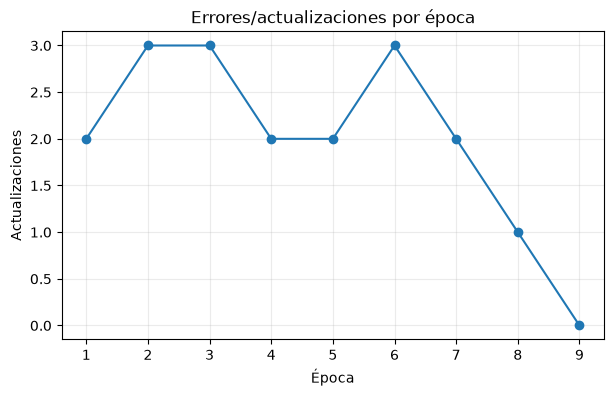

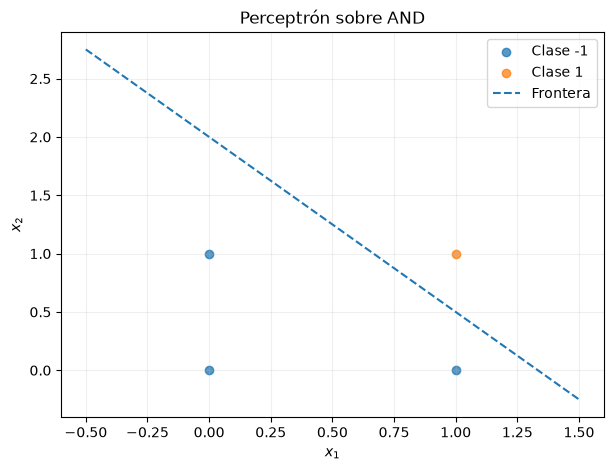

In [30]:
# Curva de errores por epoca: debe ir dismunuyendo hasta llegar a 0
graficar_errores(historial_and)
#nube de puntos + recta de frontera aprendida sobre el problema AND
graficar_frontera(
    X_and,
    y_and,
    w_and,
    "Perceptrón sobre AND",
)

### Compruebe

La frontera se obtiene de

\[
w_0+w_1x_1+w_2x_2=0.
\]

¿La recta observada separa correctamente las cuatro observaciones?  
    si, converge en entrenamiento.
¿El valor de \(w_0\) tiene una interpretación coherente con el papel del sesgo? 
    si, pues la frontera no pasa por cero.

# 8. Experimento 2: XOR

Ahora no cambiaremos **ninguna función**.

La tabla XOR es:

\[
(0,0)\mapsto -1,\quad
(0,1)\mapsto +1,\quad
(1,0)\mapsto +1,\quad
(1,1)\mapsto -1.
\]

Ejecutaremos exactamente el mismo algoritmo.

La pregunta no es solamente «¿funciona?», sino:

> si no alcanza una clasificación perfecta, ¿eso demuestra que nuestro software está mal implementado?

In [31]:
X_xor, y_xor = crear_xor()  # mismas 4 entradas que AND, pero con las etiquetas del XOR

pd.DataFrame(
    {
        "x1": X_xor[:, 0],
        "x2": X_xor[:, 1],
        "y": y_xor,
    }
)

,x1,x2,y
0,0.0,0.0,-1
1,0.0,1.0,1
2,1.0,0.0,1
3,1.0,1.0,-1


In [32]:
# ejecutamos exactamente el mismo algoritmo, sin cambiar ninguna función.
# la idea es ver que el perceptron no logra clasificar bien todo XOR, no porque el código esté mal, sino porque XOR no es linealmente separable

w_xor, historial_xor = entrenar_perceptron(
    X_xor,
    y_xor,
    eta=1.0,
    max_epocas=50,
)

pred_xor = predecir(X_xor, w_xor)

print("Pesos finales:", w_xor)
print("Exactitud:", exactitud(y_xor, pred_xor))  # normalmente quedará en 0.5 o 0.75, no en 1.0
#si esto no llega a 0, es evidencia de que el algoritmo agotó las 50 épocas sin converger
print("Errores de la última época:", historial_xor[-1]["errores"])

Pesos finales: [0. 0. 0.]
Exactitud: 0.5
Errores de la última época: 4


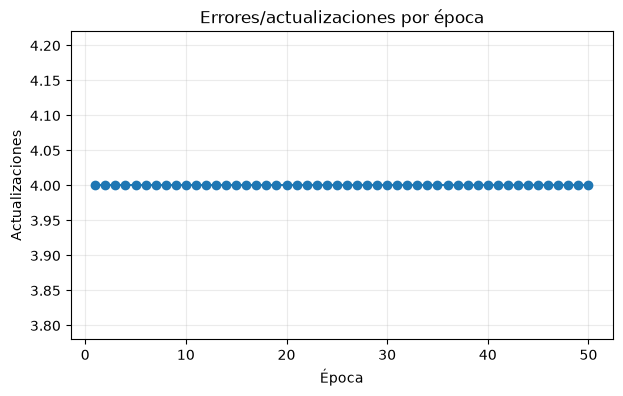

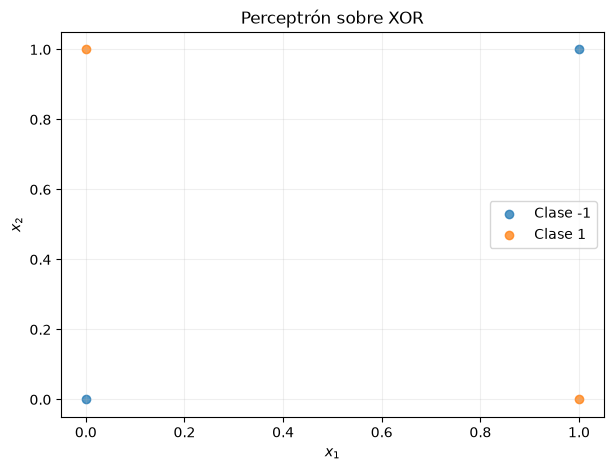

In [33]:
graficar_errores(historial_xor) # la curva de errores NO debería llegar a 0 y quedarse ahí
graficar_frontera(
    X_xor,
    y_xor,
    w_xor,
    "Perceptrón sobre XOR",
)

### Interpretación

Si las funciones ya superaron las pruebas anteriores y AND se resolvió correctamente, el comportamiento sobre XOR debe interpretarse desde la **capacidad del modelo**.

Mantenga separadas estas tres posibilidades:

\[
\boxed{
\text{bug de software}
\neq
\text{implementación matemática incorrecta}
\neq
\text{limitación de representación}.
}
\]

Un único hiperplano no puede separar XOR en el espacio original de dos dimensiones.

# 9. De cuatro observaciones a un conjunto de datos

Ahora utilizaremos el conjunto sintético observado en el EDA.

Antes de entrenar lo dividimos en:

\[
D_{\mathrm{train}}
\cup
D_{\mathrm{validation}}
\cup
D_{\mathrm{test}}.
\]

Usaremos aproximadamente:

\[
70\%\text{ train},
\qquad
15\%\text{ validation},
\qquad
15\%\text{ test}.
\]

- **Train:** es el único conjunto utilizado para modificar \(\mathbf w\).
- **Validation:** permite observar el comportamiento del modelo durante el desarrollo.
- **Test:** se reserva para una evaluación final sobre observaciones que no participaron en el entrenamiento.

La función de partición ya fue proporcionada; no debe implementarla.

In [34]:
# Partimos X_sint, y_sint (ya generados antes) en train/val/test usando las proporciones por defecto: 70%, 15%, 15%

(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
) = particion_estratificada(X_sint, y_sint)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

# verificamos que cada subconjunto sigue balanceado entre las dos clases (garantiza la partición estratificada)
print("\nDistribución train:", np.unique(y_train, return_counts=True))
print("Distribución validation:", np.unique(y_val, return_counts=True))
print("Distribución test:", np.unique(y_test, return_counts=True))

Train: (420, 2) (420,)
Validation: (90, 2) (90,)
Test: (90, 2) (90,)

Distribución train: (array([-1,  1]), array([210, 210]))
Distribución validation: (array([-1,  1]), array([45, 45]))
Distribución test: (array([-1,  1]), array([45, 45]))


In [35]:
# por ahora entrenamos solo con el conjunto de train
w_sint, historial_sint = entrenar_perceptron(
    X_train,
    y_train,
    eta=1.0,
    max_epocas=100,
)

#evaluamos el mismo modelo, con los mismos w, sobre los tres conjuntos, para comparar
pred_train = predecir(X_train, w_sint)
pred_val = predecir(X_val, w_sint)
pred_test = predecir(X_test, w_sint)

print(f"Exactitud train:      {exactitud(y_train, pred_train):.3f}")
print(f"Exactitud validation: {exactitud(y_val, pred_val):.3f}")
print(f"Exactitud test:       {exactitud(y_test, pred_test):.3f}")
print(f"Épocas ejecutadas:    {len(historial_sint)}")

Exactitud train:      1.000
Exactitud validation: 1.000
Exactitud test:       1.000
Épocas ejecutadas:    2


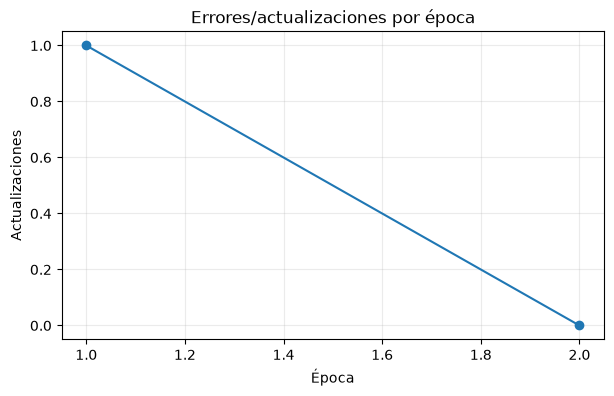

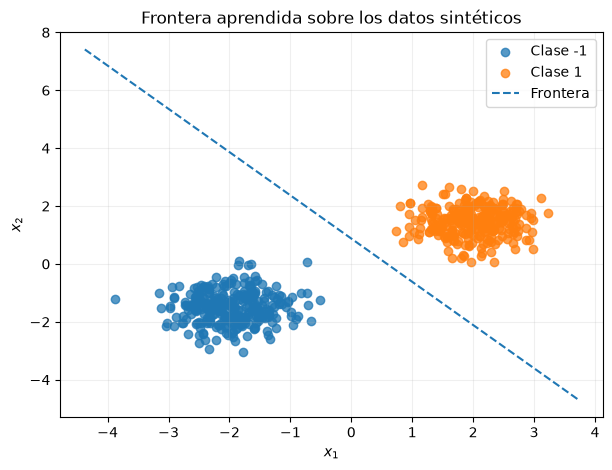

In [ ]:
#uso mis funciones de antes para errores y analizar la frontera
graficar_errores(historial_sint)
graficar_frontera(
    X_sint,    #uso sint porque no quiero ver ninguna metrica sino solo a dónde se desplazó la recta
    y_sint,
    w_sint,
    "Frontera aprendida sobre los datos sintéticos",
)

## 10. Prueba integral del cuaderno

Esta celda no reemplaza las pruebas anteriores. Su propósito es verificar que las piezas pueden conectarse.

Si llega hasta aquí sin errores, la arquitectura completa está funcionando.

In [37]:
# PRUEBA INTEGRAL — NO MODIFICAR

#queremos revisar todo el flujo de las cosas que hicimos
# 1. Contrato básico
assert validar_datos(X_train, y_train) is True   # no debe existir ningun problema con el conjunto train

# 2. Dimensiones
X_aug_final = agregar_sesgo(X_train)
assert X_aug_final.shape[1] == X_train.shape[1] + 1   #agregar el sesgo sumando una columna

# 3. Entrenamiento
w_final, hist_final = entrenar_perceptron(   #debe correr con normalidad y devolver algo con sentido
    X_train,
    y_train,
    eta=1.0,
    max_epocas=100,
)

assert len(hist_final) >= 1    #por lo menos una epoca se ejecutó
assert np.isfinite(w_final).all()    #los pesos no se dispararon a valores no definidos

# 4. Inferencia
pred_final = predecir(X_test, w_final)   
#estas predicciones sobre test tienen forma correcta y solo etiquetas dentro de {-1,+1}
assert pred_final.shape == y_test.shape
assert set(np.unique(pred_final)).issubset({-1, 1})

# 5. Este conjunto fue construido para ser linealmente separable
assert exactitud(y_test, pred_final) >= 0.95    #esperamos una exactitud alta en test, no solo en train

print("✓ La implementación completa supera la prueba integral.")

✓ La implementación completa supera la prueba integral.


# 11. Qué debe revisar antes de entregar

Antes de considerar terminado el ejercicio:

1. reinicie el kernel;
2. ejecute **Run All**;
3. compruebe que no aparece ningún error;
4. verifique que AND converge;
5. interprete correctamente el resultado de XOR;
6. compruebe las métricas sobre train, validation y test;
7. revise que no modificó firmas, `return` ni pruebas;
8. no suba el ambiente virtual al repositorio.

Puede revisar el estado del proyecto con:

```bash
git status
```

Después:

```bash
git add .
git commit -m "Completa implementación funcional del perceptrón"
git pull
git push
```

Si `git pull` produce un conflicto, **no borre archivos ni fuerce el `push` sin entender qué ocurrió**.

---

## Criterio de finalización

El objetivo no es que una celda aislada produzca un número correcto.  
El ejercicio está completo cuando:

\[
\boxed{
\text{datos}
\rightarrow
\text{validación}
\rightarrow
\text{entrenamiento}
\rightarrow
\text{inferencia}
\rightarrow
\text{evaluación}
}
\]

puede ejecutarse como un flujo coherente.

En el siguiente ejercicio del curso esta arquitectura ya no será entregada: deberán proponerla ustedes a partir de la formulación matemática de un nuevo modelo.